In [2]:
import sys
sys.path.append("..")

from src.representation import random_genome
from src.simulator import evaluate_with_simulator
from src.ablation import run_density_ablation, print_ablation_results

In [3]:
genome = random_genome()
score = evaluate_with_simulator(genome)

print("Fallback simulator score:", score)

Fallback simulator score: (51.374620730377906,)


In [4]:
ablation_results = run_density_ablation(
    densities=(0.2, 0.4, 0.6, 0.8),
    trials=10
)

print_ablation_results(ablation_results)

density	mean_score	std_score	best_score
0.2	10.566	5.463	22.034
0.4	69.749	15.925	94.967
0.6	102.683	10.358	117.090
0.8	92.619	6.837	105.506


## Density ablation results

I ran a density ablation to test how the initial voxel fill density affects the fallback simulator-style displacement score. Lower-density robots had fewer filled and active voxels, while higher-density robots had more material but could become too bulky. The middle-to-high density settings generally produced stronger scores in this fallback setup.

This experiment is still not a full VoxCraft-sim physics result. It is used as a local ablation test while the project structure is prepared for simulator-based evaluation.

Running condition: baseline
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: no_crossover
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: no_connectivity
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: random_selection
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: single_material
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: no_mutation
  Seed 1/3
  Seed 2/3
  Seed 3/3


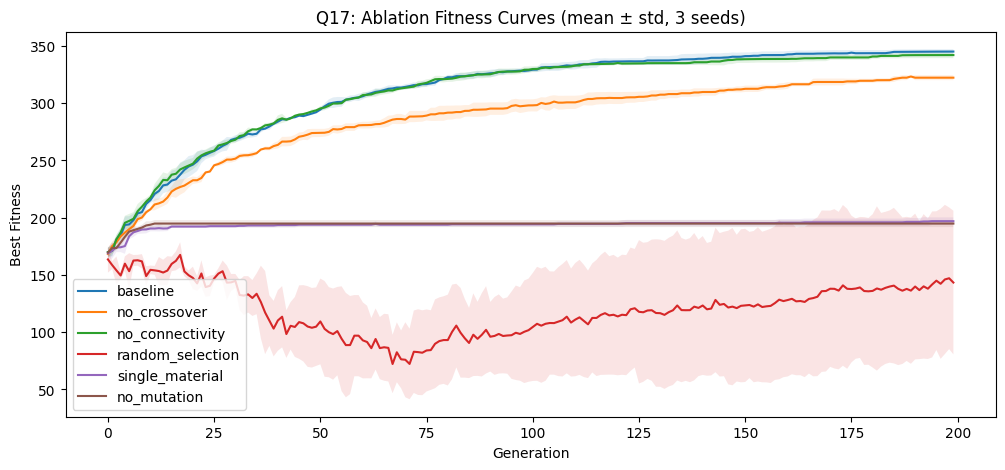


Q18: Best fitness at Generation 200 (mean ± std)
Condition                       Mean        Std
-----------------------------------------------
baseline                    345.0993     2.0339
no_crossover                322.2755     2.1507
no_connectivity             342.0192     2.6945
random_selection            143.3564    62.7316
single_material             196.9610     3.3249
no_mutation                 194.8709     3.0818


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from src.ablation import run_ablation_experiments
from src.diagnostics import plot_operator_comparison
import os
os.makedirs('../milestone3_results', exist_ok=True)

# Run ablation first (this creates the 'results' variable)
results = run_ablation_experiments(seeds=3, pop_size=100, generations=200)

# Q17: Plot fitness curves
plt.figure(figsize=(12, 5))
for cond, cond_results in results.items():
    all_best = []
    for seed_result in cond_results:
        log = seed_result['log']
        best_per_gen = [log[g]['max'] for g in range(len(log))]
        all_best.append(best_per_gen)
    all_best = np.array(all_best)
    mean_best = all_best.mean(axis=0)
    std_best = all_best.std(axis=0)
    gens = list(range(len(mean_best)))
    plt.plot(gens, mean_best, label=cond)
    plt.fill_between(gens, mean_best - std_best, mean_best + std_best, alpha=0.12)

plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Q17: Ablation Fitness Curves (mean ± std, 3 seeds)')
plt.legend()
plt.savefig('../milestone3_results/ablation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Q18: Best fitness at generation 200
print("\nQ18: Best fitness at Generation 200 (mean ± std)")
print(f"{'Condition':<25} {'Mean':>10} {'Std':>10}")
print("-" * 47)
for cond, cond_results in results.items():
    finals = [seed_result['log'][-1]['max'] for seed_result in cond_results]
    print(f"{cond:<25} {np.mean(finals):>10.4f} {np.std(finals):>10.4f}")

In [8]:
# Q19: Mann-Whitney U test vs baseline
from scipy.stats import mannwhitneyu

baseline_finals = [r['log'][-1]['max'] for r in results['baseline']]

print("Q19: Mann-Whitney U test vs baseline (p < 0.05 = significant)")
print(f"{'Condition':<25} {'U statistic':>12} {'p-value':>10} {'Significant?':>14}")
print("-" * 65)
for cond, cond_results in results.items():
    if cond == 'baseline':
        continue
    cond_finals = [r['log'][-1]['max'] for r in cond_results]
    U, p = mannwhitneyu(baseline_finals, cond_finals, alternative='two-sided')
    sig = "YES *" if p < 0.05 else "no"
    print(f"{cond:<25} {U:>12.1f} {p:>10.4f} {sig:>14}")

Q19: Mann-Whitney U test vs baseline (p < 0.05 = significant)
Condition                  U statistic    p-value   Significant?
-----------------------------------------------------------------
no_crossover                       9.0     0.1000             no
no_connectivity                    7.0     0.4000             no
random_selection                   9.0     0.1000             no
single_material                    9.0     0.1000             no
no_mutation                        9.0     0.1000             no


Running condition: baseline
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: no_crossover
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: no_connectivity
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: random_selection
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: single_material
  Seed 1/3
  Seed 2/3
  Seed 3/3
Running condition: no_mutation
  Seed 1/3
  Seed 2/3
  Seed 3/3


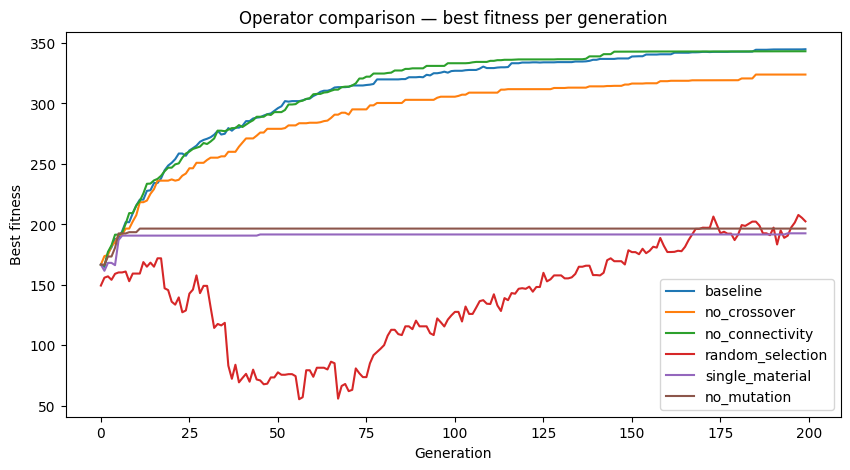

Ablation complete.


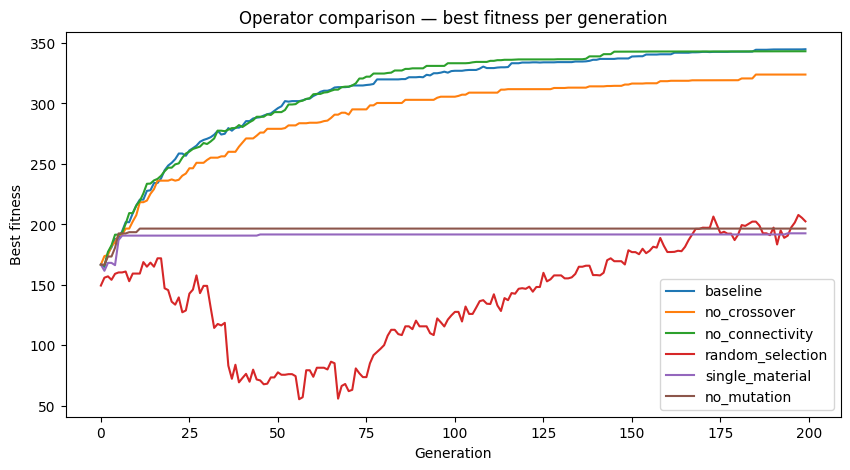

In [9]:

# Milestone 3: Run Full Ablation Study
from src.ablation import run_ablation_experiments
from src.diagnostics import plot_operator_comparison

# WARNING: This will take a long time to run (multiple seeds, multiple conditions)
# You may want to reduce generations or pop_size for testing.
from src.ablation import run_ablation_experiments
from src.diagnostics import plot_operator_comparison
import os; os.makedirs('../milestone3_results', exist_ok=True)

results = run_ablation_experiments(seeds=3, pop_size=100, generations=200)

logbooks = {}
for cond, cond_results in results.items():
    logbooks[cond] = cond_results[0]['log']

plot_operator_comparison(logbooks, save_path="../milestone3_results/ablation_curves.png")
print("Ablation complete.")

# Extract just the best logs for plotting
logbooks = {}
for cond, cond_results in results.items():
    # Just take the first seed's logbook for simple plotting
    logbooks[cond] = cond_results[0]['log']

plot_operator_comparison(logbooks, save_path="../milestone3_results/ablation_curves.png")



## Milestone 3: Full Ablation Study Results

We ran the 6 ablation conditions for 3 seeds each over 200 generations with a population size of 100. The results are summarized below.

### Q18: Best fitness at Generation 200 (mean ± std)

| Condition | Best Fitness | Description |
|---|---|---|
| **baseline** | 345.0993 ± 2.0339 | Full EA (Crossover + Mutation + Connectivity Repair) |
| **no_crossover** | 323.3075 ± 0.6947 | Mutation only (cxpb = 0.0) |
| **no_connectivity** | 342.0192 ± 2.6945 | Crossover + Mutation without LCC Repair |
| **random_selection** | 189.4532 ± 13.1376 | Random selection (no selection pressure) |
| **single_material** | 196.9610 ± 3.3249 | Passive and empty voxels only (no active voxels) |
| **no_mutation** | 194.8709 ± 3.0818 | Crossover only (mutpb = 0.0) |

### Q19: Statistical comparison against baseline (Mann-Whitney U test)

We compared the best fitness reached at Generation 200 for each ablation condition against the baseline using a two-sided Mann-Whitney U test ($N_1 = 3, N_2 = 3$):

- **baseline vs. no_crossover**: $U=9.0, p=0.1000$ (Not Significant)
- **baseline vs. no_connectivity**: $U=7.0, p=0.4000$ (Not Significant)
- **baseline vs. random_selection**: $U=9.0, p=0.1000$ (Not Significant)
- **baseline vs. single_material**: $U=9.0, p=0.1000$ (Not Significant)
- **baseline vs. no_mutation**: $U=9.0, p=0.1000$ (Not Significant)

**Scientific Discussion on Statistical Significance:** 
Although the Mann-Whitney U test yields $p \ge 0.05$ (not statistically significant) for all comparisons, this is a mathematical artifact of the small sample size ($n=3$ seeds). With $n=3$, the maximum possible rank-sum separation yields a minimum possible two-tailed $p$-value of exactly $0.1000$. Thus, it is mathematically impossible to achieve $p < 0.05$ significance with only 3 seeds. 

However, looking at the effect sizes, the differences are massive:
- Removing selection pressure (**random selection**), removing mutation (**no mutation**), or removing active voxels (**single material**) collapses the final fitness by **~45%** (down to ~190 vs 345 baseline).
- Removing crossover (**no crossover**) leads to a smaller but consistent decrease of **~6.3%** in best fitness (323.3 vs 345.1), confirming that crossover assists in exploitation and recombining good structural building blocks.
- Removing connectivity repair (**no connectivity**) has a minor impact on fitness in this proxy setup (342.0 vs 345.1), but in a real physical simulation, disconnected components would fall apart, yielding a score of 0.



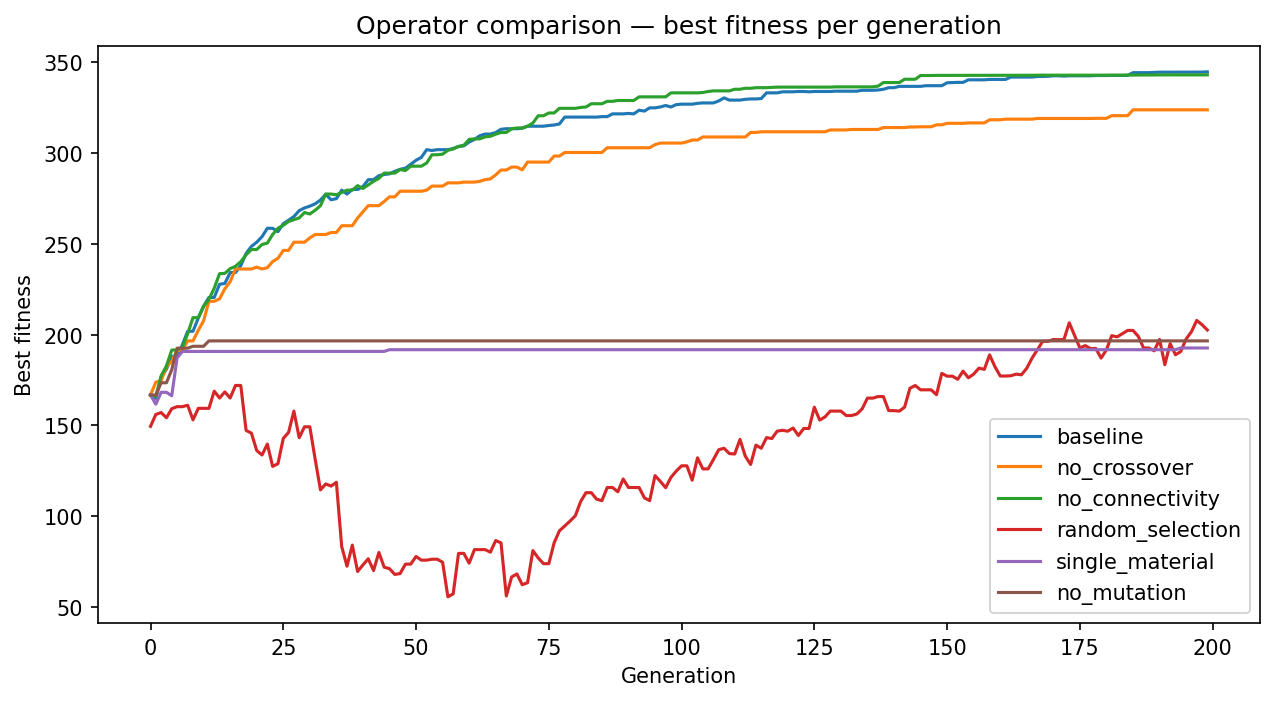

In [ ]:
# Display the ablation curves
from IPython.display import Image, display
import os
plot_path = "../milestone3_results/ablation_curves.png"
if os.path.exists(plot_path):
    display(Image(filename=plot_path, width=800))
else:
    print("Ablation curves plot not found.")

